# Home Credit Loan Decision Engine — Test Predictions

Apply the trained loan-risk model to unseen applicant data and generate predictions using the same feature pipeline used during model development.

This notebook takes `application_test.csv`, processes the applicant and credit-history data, applies the saved preprocessing configuration and trained LightGBM model, and generates a submission-ready prediction file matching the format of `sample_submission.csv`.

The test set does not contain `TARGET`, so these predictions cannot be evaluated locally against ground truth.

## 0. Environment Setup

Load the libraries, project paths, trained model, and preprocessing artifacts required for batch prediction.

In [1]:
import re
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
import matplotlib.pyplot as plt

DATA_DIR = Path("../data")
MODELS_DIR = Path("../models")

## A. Load Test Data

Load `application_test.csv` containing 48,744 unseen applicants.

The test data does not include the `TARGET` variable because these records are used only for inference.

All available test applicants are retained so that every applicant receives a prediction.

In [2]:
app_test_raw = pd.read_csv(DATA_DIR / "application_test.csv")
print("test shape:", app_test_raw.shape)
print("XNA gender rows:", (app_test_raw["CODE_GENDER"] == "XNA").sum(), "-- kept, every row needs a prediction")

test shape: (48744, 121)
XNA gender rows: 0 -- kept, every row needs a prediction


## B. Build Applicant Features

Combine the test applicants with their available credit-history data from the related Home Credit tables.

Use the same aggregation logic as the training pipeline so that training and inference produce a consistent feature structure.

In [3]:
bureau = pd.read_csv(DATA_DIR / "bureau.csv")

bureau_agg = bureau.groupby("SK_ID_CURR").agg(
    BUREAU_COUNT=("SK_ID_BUREAU", "count"),
    BUREAU_ACTIVE_COUNT=("CREDIT_ACTIVE", lambda x: (x == "Active").sum()),
    BUREAU_CLOSED_COUNT=("CREDIT_ACTIVE", lambda x: (x == "Closed").sum()),
    BUREAU_CREDIT_TYPE_NUNIQUE=("CREDIT_TYPE", "nunique"),
    BUREAU_DAYS_CREDIT_MEAN=("DAYS_CREDIT", "mean"),
    BUREAU_DAYS_CREDIT_MIN=("DAYS_CREDIT", "min"),
    BUREAU_CREDIT_DAY_OVERDUE_MAX=("CREDIT_DAY_OVERDUE", "max"),
    BUREAU_CREDIT_DAY_OVERDUE_SUM=("CREDIT_DAY_OVERDUE", "sum"),
    BUREAU_CNT_CREDIT_PROLONG_SUM=("CNT_CREDIT_PROLONG", "sum"),
    BUREAU_AMT_CREDIT_SUM_TOTAL=("AMT_CREDIT_SUM", "sum"),
    BUREAU_AMT_CREDIT_SUM_DEBT_TOTAL=("AMT_CREDIT_SUM_DEBT", "sum"),
    BUREAU_AMT_CREDIT_SUM_OVERDUE_TOTAL=("AMT_CREDIT_SUM_OVERDUE", "sum"),
).reset_index()
bureau_agg["BUREAU_ACTIVE_RATIO"] = bureau_agg["BUREAU_ACTIVE_COUNT"] / bureau_agg["BUREAU_COUNT"]

bb = pd.read_csv(DATA_DIR / "bureau_balance.csv")
bb["IS_DPD"] = bb["STATUS"].isin(["1", "2", "3", "4", "5"]).astype(int)
bb["DPD_SEVERITY"] = bb["STATUS"].replace({"C": -1, "X": -1, "0": 0}).astype(int)

bb_agg = bb.groupby("SK_ID_BUREAU").agg(
    BB_MONTHS_COUNT=("MONTHS_BALANCE", "count"),
    BB_DPD_MONTHS_COUNT=("IS_DPD", "sum"),
    BB_MAX_DPD_SEVERITY=("DPD_SEVERITY", "max"),
).reset_index()
most_recent = (
    bb.sort_values("MONTHS_BALANCE").groupby("SK_ID_BUREAU").tail(1)
    [["SK_ID_BUREAU", "DPD_SEVERITY"]].rename(columns={"DPD_SEVERITY": "BB_MOST_RECENT_STATUS_SEVERITY"})
)
bb_agg = bb_agg.merge(most_recent, on="SK_ID_BUREAU", how="left")
bb_agg["BB_DPD_RATIO"] = bb_agg["BB_DPD_MONTHS_COUNT"] / bb_agg["BB_MONTHS_COUNT"]

bureau_bb = bureau[["SK_ID_CURR", "SK_ID_BUREAU"]].merge(bb_agg, on="SK_ID_BUREAU", how="left")
client_bb_agg = bureau_bb.groupby("SK_ID_CURR").agg(
    BUREAU_BB_MONTHS_MEAN=("BB_MONTHS_COUNT", "mean"),
    BUREAU_BB_MAX_DPD_SEVERITY=("BB_MAX_DPD_SEVERITY", "max"),
    BUREAU_BB_DPD_RATIO_MEAN=("BB_DPD_RATIO", "mean"),
    BUREAU_BB_MOST_RECENT_SEVERITY_MAX=("BB_MOST_RECENT_STATUS_SEVERITY", "max"),
).reset_index()

app_test = app_test_raw.merge(bureau_agg, on="SK_ID_CURR", how="left").merge(client_bb_agg, on="SK_ID_CURR", how="left")
app_test["HAS_BUREAU_HISTORY"] = app_test["BUREAU_COUNT"].notna().astype(int)
print("after bureau + bureau_balance:", app_test.shape)

after bureau + bureau_balance: (48744, 139)


In [4]:
# previous_application
prev = pd.read_csv(DATA_DIR / "previous_application.csv")
prev["IS_APPROVED"] = (prev["NAME_CONTRACT_STATUS"] == "Approved").astype(int)
prev["IS_REFUSED"] = (prev["NAME_CONTRACT_STATUS"] == "Refused").astype(int)
prev["CREDIT_TO_APPLICATION_RATIO"] = prev["AMT_CREDIT"] / prev["AMT_APPLICATION"].replace(0, np.nan)

prev_agg = prev.groupby("SK_ID_CURR").agg(
    PREV_COUNT=("SK_ID_PREV", "count"),
    PREV_APPROVED_RATIO=("IS_APPROVED", "mean"),
    PREV_REFUSED_RATIO=("IS_REFUSED", "mean"),
    PREV_AMT_APPLICATION_MEAN=("AMT_APPLICATION", "mean"),
    PREV_AMT_CREDIT_MEAN=("AMT_CREDIT", "mean"),
    PREV_AMT_ANNUITY_MEAN=("AMT_ANNUITY", "mean"),
    PREV_DAYS_DECISION_MEAN=("DAYS_DECISION", "mean"),
    PREV_DAYS_DECISION_MIN=("DAYS_DECISION", "min"),
    PREV_CNT_PAYMENT_MEAN=("CNT_PAYMENT", "mean"),
    PREV_CREDIT_TO_APPLICATION_RATIO_MEAN=("CREDIT_TO_APPLICATION_RATIO", "mean"),
).reset_index()

# POS_CASH_balance
pos = pd.read_csv(DATA_DIR / "POS_CASH_balance.csv")
pos["IS_DPD"] = (pos["SK_DPD"] > 0).astype(int)
pos_agg = pos.groupby("SK_ID_CURR").agg(
    POS_MONTHS_COUNT=("MONTHS_BALANCE", "count"),
    POS_CONTRACTS_COUNT=("SK_ID_PREV", "nunique"),
    POS_SK_DPD_MAX=("SK_DPD", "max"),
    POS_SK_DPD_MEAN=("SK_DPD", "mean"),
    POS_SK_DPD_DEF_MAX=("SK_DPD_DEF", "max"),
    POS_DPD_MONTHS_RATIO=("IS_DPD", "mean"),
    POS_CNT_INSTALMENT_MEAN=("CNT_INSTALMENT", "mean"),
).reset_index()

# installments_payments
inst = pd.read_csv(DATA_DIR / "installments_payments.csv")
inst["DAYS_LATE"] = inst["DAYS_ENTRY_PAYMENT"] - inst["DAYS_INSTALMENT"]
inst["IS_LATE"] = (inst["DAYS_LATE"] > 0).astype(int)
inst["PAYMENT_RATIO"] = inst["AMT_PAYMENT"] / inst["AMT_INSTALMENT"].replace(0, np.nan)
inst["IS_UNDERPAID"] = (inst["PAYMENT_RATIO"] < 0.99).astype(int)
inst_agg = inst.groupby("SK_ID_CURR").agg(
    INST_COUNT=("NUM_INSTALMENT_NUMBER", "count"),
    INST_DAYS_LATE_MEAN=("DAYS_LATE", "mean"),
    INST_DAYS_LATE_MAX=("DAYS_LATE", "max"),
    INST_LATE_RATIO=("IS_LATE", "mean"),
    INST_PAYMENT_RATIO_MEAN=("PAYMENT_RATIO", "mean"),
    INST_UNDERPAID_RATIO=("IS_UNDERPAID", "mean"),
    INST_AMT_INSTALMENT_MEAN=("AMT_INSTALMENT", "mean"),
).reset_index()

# credit_card_balance
cc = pd.read_csv(DATA_DIR / "credit_card_balance.csv")
cc["UTILIZATION"] = cc["AMT_BALANCE"] / cc["AMT_CREDIT_LIMIT_ACTUAL"].replace(0, np.nan)
cc["IS_DPD"] = (cc["SK_DPD"] > 0).astype(int)
cc_agg = cc.groupby("SK_ID_CURR").agg(
    CC_MONTHS_COUNT=("MONTHS_BALANCE", "count"),
    CC_AMT_BALANCE_MEAN=("AMT_BALANCE", "mean"),
    CC_CREDIT_LIMIT_MEAN=("AMT_CREDIT_LIMIT_ACTUAL", "mean"),
    CC_UTILIZATION_MEAN=("UTILIZATION", "mean"),
    CC_UTILIZATION_MAX=("UTILIZATION", "max"),
    CC_SK_DPD_MAX=("SK_DPD", "max"),
    CC_DPD_MONTHS_RATIO=("IS_DPD", "mean"),
    CC_AMT_DRAWINGS_CURRENT_MEAN=("AMT_DRAWINGS_CURRENT", "mean"),
    CC_AMT_PAYMENT_TOTAL_MEAN=("AMT_PAYMENT_TOTAL_CURRENT", "mean"),
).reset_index()

app_test = (
    app_test.merge(prev_agg, on="SK_ID_CURR", how="left")
        .merge(pos_agg, on="SK_ID_CURR", how="left")
        .merge(inst_agg, on="SK_ID_CURR", how="left")
        .merge(cc_agg, on="SK_ID_CURR", how="left")
)
app_test["HAS_PREV_APPLICATION"] = app_test["PREV_COUNT"].notna().astype(int)
app_test["HAS_POS_CASH"] = app_test["POS_MONTHS_COUNT"].notna().astype(int)
app_test["HAS_INSTALMENTS"] = app_test["INST_COUNT"].notna().astype(int)
app_test["HAS_CREDIT_CARD"] = app_test["CC_MONTHS_COUNT"].notna().astype(int)

print("merged test (raw, uncleaned):", app_test.shape)

merged test (raw, uncleaned): (48744, 176)


## C. Apply Training-Time Data Preparation

Apply the same data-cleaning rules used during model development.

Training-derived values are used for:

- Selecting the retained raw features.
- Filling missing values.
- Maintaining a consistent feature definition.

No statistics are recalculated from the test set.

This keeps the inference pipeline consistent with the model's training environment and prevents test-set information from influencing preprocessing.

In [5]:
SENTINEL = 365243
app_test["DAYS_EMPLOYED_ANOM"] = (app_test["DAYS_EMPLOYED"] == SENTINEL).astype(int)
app_test.loc[app_test["DAYS_EMPLOYED"] == SENTINEL, "DAYS_EMPLOYED"] = np.nan

full_schema_train = pd.read_csv(DATA_DIR / "processed" / "application_train_full_schema.csv")
train_medians = full_schema_train.median(numeric_only=True)

raw_app_cols = [c for c in app_test_raw.columns if c != "SK_ID_CURR"]
dropped_raw_cols = [c for c in raw_app_cols if c not in full_schema_train.columns]
print(f"dropping {len(dropped_raw_cols)} raw columns (same ones training dropped)")
app_test = app_test.drop(columns=[c for c in dropped_raw_cols if c in app_test.columns])

for col in app_test.columns:
    if app_test[col].isna().any():
        if pd.api.types.is_numeric_dtype(app_test[col]):
            app_test[f"{col}_WAS_MISSING"] = app_test[col].isna().astype(int)
            app_test[col] = app_test[col].fillna(train_medians.get(col, app_test[col].median()))
        else:
            app_test[col] = app_test[col].fillna("Missing")

print("cleaned test:", app_test.shape, "| missing remaining:", app_test.isna().sum().sum())

dropping 17 raw columns (same ones training dropped)
cleaned test: (48744, 253) | missing remaining: 0


/var/folders/bs/rr857q5d301gvpj36wf7mfx00000gn/T/ipykernel_69321/145337706.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app_test[f"{col}_WAS_MISSING"] = app_test[col].isna().astype(int)
/var/folders/bs/rr857q5d301gvpj36wf7mfx00000gn/T/ipykernel_69321/145337706.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app_test[f"{col}_WAS_MISSING"] = app_test[col].isna().astype(int)
/var/folders/bs/rr857q5d301gvpj36wf7mfx00000gn/T/ipykernel_69321/145337706.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usu

## D. Create Derived Risk Features

Generate the same domain-based features used during training:

- Credit-to-income ratio
- Annuity-to-income ratio
- Implied loan term
- Employment-to-age ratio

These features are calculated directly from each applicant's available data using the same formulas defined in the training pipeline.

In [6]:
app_test['CREDIT_INCOME_PERCENT'] = app_test['AMT_CREDIT'] / app_test['AMT_INCOME_TOTAL'].replace(0, np.nan)
app_test['ANNUITY_INCOME_PERCENT'] = app_test['AMT_ANNUITY'] / app_test['AMT_INCOME_TOTAL'].replace(0, np.nan)
app_test['CREDIT_TERM'] = app_test['AMT_ANNUITY'] / app_test['AMT_CREDIT'].replace(0, np.nan)
app_test['DAYS_EMPLOYED_PERCENT'] = app_test['DAYS_EMPLOYED'] / app_test['DAYS_BIRTH'].replace(0, np.nan)

domain_cols = ['CREDIT_INCOME_PERCENT', 'ANNUITY_INCOME_PERCENT', 'CREDIT_TERM', 'DAYS_EMPLOYED_PERCENT']
for col in domain_cols:
    if app_test[col].isna().any():
        app_test[col] = app_test[col].fillna(train_medians.get(col, app_test[col].median()))
display(app_test[domain_cols].describe())

/var/folders/bs/rr857q5d301gvpj36wf7mfx00000gn/T/ipykernel_69321/3534416407.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app_test['CREDIT_INCOME_PERCENT'] = app_test['AMT_CREDIT'] / app_test['AMT_INCOME_TOTAL'].replace(0, np.nan)
/var/folders/bs/rr857q5d301gvpj36wf7mfx00000gn/T/ipykernel_69321/3534416407.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app_test['ANNUITY_INCOME_PERCENT'] = app_test['AMT_ANNUITY'] / app_test['AMT_INCOME_TOTAL'].replace(0, np.nan)
/var/folders/bs/rr857q5d301gvpj36wf7mfx00000gn/T/ipykernel

,CREDIT_INCOME_PERCENT,ANNUITY_INCOME_PERCENT,CREDIT_TERM,DAYS_EMPLOYED_PERCENT
count,48744.000000,48744.000000,48744.000000,48744.000000
mean,3.167544,0.182974,0.066633,0.147161
std,2.137173,0.095473,0.024598,0.124267
min,0.092500,0.005730,0.013835,0.000081
25%,1.695695,0.116320,0.048542,0.069468
50%,2.666143,0.165920,0.061436,0.096761
75%,4.029600,0.229829,0.079442,0.199510
max,30.445000,2.024714,0.238864,0.721157


## E. Prepare Model Input

Transform the test data into the exact feature structure expected by the trained model. This includes:

1. Encoding categorical variables.
2. Applying the selected feature set.
3. Aligning feature names and column order with the training data.
4. Handling categories that were not present during training.

The resulting feature matrix is ready for model inference.

In [7]:
with open(DATA_DIR / "processed" / "selected_features_full.txt") as f:
    raw_selected_features = f.read().splitlines()

missing_needed = [c for c in raw_selected_features if c not in app_test.columns]
print("selected raw fields missing from test (should be empty):", missing_needed)

test_selected = app_test[["SK_ID_CURR"] + raw_selected_features].copy()
sel_cat_cols = test_selected.select_dtypes(include="object").columns.tolist()
test_encoded = pd.get_dummies(test_selected, columns=sel_cat_cols, drop_first=True)
test_encoded.columns = [re.sub(r"[^A-Za-z0-9_]+", "_", c) for c in test_encoded.columns]

model_ready_cols = pd.read_csv(DATA_DIR / "processed" / "application_train_model_ready_full.csv", nrows=0).columns.tolist()
model_ready_cols = [c for c in model_ready_cols if c not in ("SK_ID_CURR", "TARGET")]

X_test = test_encoded.reindex(columns=model_ready_cols, fill_value=0).astype(float)
print("test feature matrix:", X_test.shape, "| model expects:", len(model_ready_cols), "columns")

selected raw fields missing from test (should be empty): []
test feature matrix: (48744, 74) | model expects: 74 columns


## F. Generate Predictions

Load the trained LightGBM model and generate a risk prediction for each test applicant.

The model is used for inference only — it is not retrained or refitted on the test data.

Generate the prediction output using the applicant ID and predicted risk probability.

In [8]:
model = joblib.load(MODELS_DIR / "lightgbm_full_schema_tuned.joblib")
test_proba = model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({"SK_ID_CURR": app_test["SK_ID_CURR"], "TARGET": test_proba})
print("submission shape:", submission.shape)
display(submission.head())

submission shape: (48744, 2)


,SK_ID_CURR,TARGET
0,100001,0.226198
1,100005,0.600643
2,100013,0.156614
3,100028,0.189540
4,100038,0.657177


In [9]:
sample = pd.read_csv(DATA_DIR / "sample_submission.csv")
print("same columns as sample_submission.csv:", list(submission.columns) == list(sample.columns))
print("same row count as sample_submission.csv:", len(submission) == len(sample))
print("same SK_ID_CURR set:", set(submission["SK_ID_CURR"]) == set(sample["SK_ID_CURR"]))
print("\npredicted probability distribution:")
display(submission["TARGET"].describe())

same columns as sample_submission.csv: True
same row count as sample_submission.csv: True
same SK_ID_CURR set: True

predicted probability distribution:


count    48744.000000
mean         0.372316
std          0.214116
min          0.009987
25%          0.193253
50%          0.338438
75%          0.531181
max          0.947040
Name: TARGET, dtype: float64

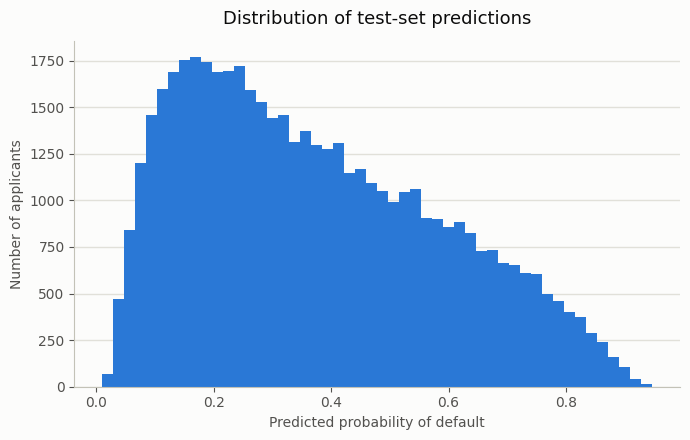

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(submission["TARGET"], bins=50, color="#2a78d6")
ax.set_xlabel("Predicted probability of default", color="#52514e")
ax.set_ylabel("Number of applicants", color="#52514e")
ax.set_title("Distribution of test-set predictions", color="#0b0b0b", fontsize=13, pad=12)
ax.spines[["top", "right"]].set_visible(False)
ax.spines["left"].set_color("#c3c2b7")
ax.spines["bottom"].set_color("#c3c2b7")
ax.tick_params(colors="#52514e")
ax.yaxis.grid(True, color="#e1e0d9", linewidth=1)
ax.set_axisbelow(True)
fig.patch.set_facecolor("#fcfcfb")
ax.set_facecolor("#fcfcfb")
plt.tight_layout()
plt.show()

In [11]:
submission.to_csv(DATA_DIR / "processed" / "test_predictions_submission.csv", index=False)
print("saved to data/processed/test_predictions_submission.csv")

saved to data/processed/test_predictions_submission.csv


## G. Prediction Output

Generate predictions for all 48,744 test applicants using the same trained model and feature pipeline used during development.

Validate the output against `sample_submission.csv` to confirm that:

- The expected columns are present.
- The applicant IDs match the test set.
- The number of predictions matches the number of applicants.
- The output is saved in the required format.

Because the test set does not contain `TARGET`, model performance cannot be measured locally on these predictions.

The resulting file represents the final batch-inference output from the trained loan-risk model.